In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from aquarel import load_theme
from pathlib import Path

DATA_PATH = Path("../data/games.csv")

theme = load_theme("arctic_light")
theme.apply()
df = pd.read_csv(DATA_PATH)
df.head()

,Unnamed: 0,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


## What the dataset is about

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         1512 non-null   int64  
 1   Title              1512 non-null   str    
 2   Release Date       1512 non-null   str    
 3   Team               1511 non-null   str    
 4   Rating             1499 non-null   float64
 5   Times Listed       1512 non-null   str    
 6   Number of Reviews  1512 non-null   str    
 7   Genres             1512 non-null   str    
 8   Summary            1511 non-null   str    
 9   Reviews            1512 non-null   str    
 10  Plays              1512 non-null   str    
 11  Playing            1512 non-null   str    
 12  Backlogs           1512 non-null   str    
 13  Wishlist           1512 non-null   str    
dtypes: float64(1), int64(1), str(12)
memory usage: 165.5 KB


In [3]:
df.describe(include=["float64"])

,Rating
count,1499.000000
mean,3.719346
std,0.532608
min,0.700000
25%,3.400000
50%,3.800000
75%,4.100000
max,4.800000


In [4]:
df.size

21168

In [5]:
df.shape

(1512, 14)

## Cleaning the data

In [6]:
df.dropna(inplace=True)
df.drop_duplicates(subset="Title", keep="first", inplace=True)

In [7]:
df.isna().sum()

Unnamed: 0           0
Title                0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
dtype: int64

In [8]:
# drop unnamed column
df.drop("Unnamed: 0", axis=1, inplace=True)

In [9]:
df.shape

(1085, 13)

In [10]:
# converting release data
df["Release Date"] = pd.to_datetime(df["Release Date"], errors="coerce", format="%b %d, %Y")
df["Release Year"] = df["Release Date"].dt.year

df.head()

,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist,Release Year
0,Elden Ring,2022-02-25,"['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K,2022.0
1,Hades,2019-12-10,['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K,2019.0
2,The Legend of Zelda: Breath of the Wild,2017-03-03,"['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K,2017.0
3,Undertale,2015-09-15,"['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K,2015.0
4,Hollow Knight,2017-02-24,['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K,2017.0


In [11]:
df.columns

Index(['Title', 'Release Date', 'Team', 'Rating', 'Times Listed',
       'Number of Reviews', 'Genres', 'Summary', 'Reviews', 'Plays', 'Playing',
       'Backlogs', 'Wishlist', 'Release Year'],
      dtype='str')

In [12]:
# converting string values to numeric
def convert_k(value):
    value = str(value).replace(",", "").strip()
    
    if "K" in value:
        return float(value.replace("K", "")) * 1000
    return float(value)

cols = ["Times Listed", "Number of Reviews", "Plays", "Playing", "Backlogs", "Wishlist"]

for col in cols:
    df[col] = df[col].apply(convert_k)

In [13]:
df.Team = df.Team.str.replace("[", "").str.replace("'", "", regex=False)
df.Team = df.Team.str.replace("]", "", regex=False)

# handling different team types
team_df = df.copy()
team_df["Team"] = df["Team"].str.split(",")
team_df = team_df.explode("Team")
team_df["Team"] = team_df["Team"].str.strip()

In [14]:
# handling different genres
df.Genres = df.Genres.str.replace("[", "").str.replace("'", "", regex=False)
df.Genres = df.Genres.str.replace("]", "", regex=False)

genres_df = df.copy()
genres_df["Genres"] = df["Genres"].str.split(",")
genres_df = genres_df.explode("Genres")
genres_df["Genres"] = genres_df["Genres"].str.strip()
genres_df = genres_df[genres_df["Genres"] != ""]


## Top Rated Games

Which games have the highest ratings?

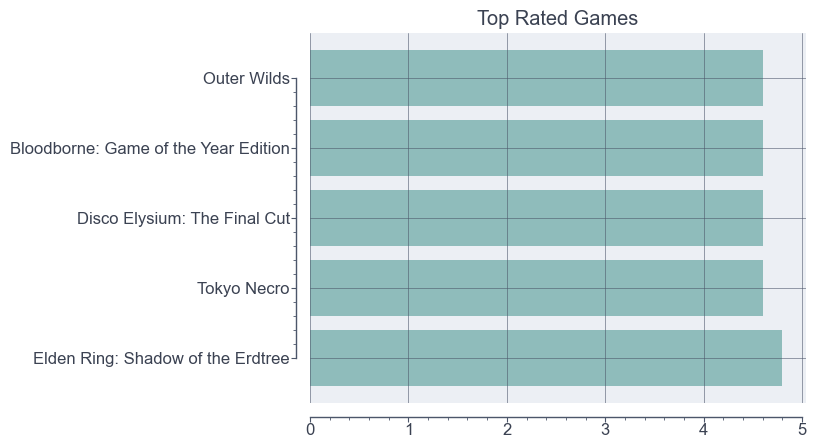

In [15]:
best_five_rated_games_df = df.sort_values(by="Rating", ascending=False).iloc[0:5, :].reset_index()

plt.barh(best_five_rated_games_df.Title, best_five_rated_games_df.Rating)
theme.apply_transforms()
plt.title("Top Rated Games")
plt.show()

Which studios appear most in top-rated games?

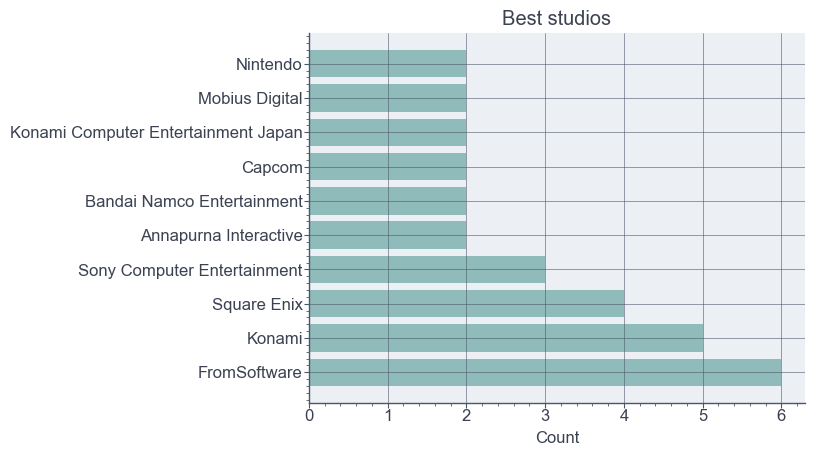

In [16]:
best_ten_studios = team_df[team_df.Rating > 4.4].groupby("Team").size().nlargest(10)

plt.barh(best_ten_studios.index, best_ten_studios.values)
plt.title("Best studios")
plt.xlabel("Count")
plt.show()

## Most Commong Genres

Which genres dominate? Are RPGs most common?

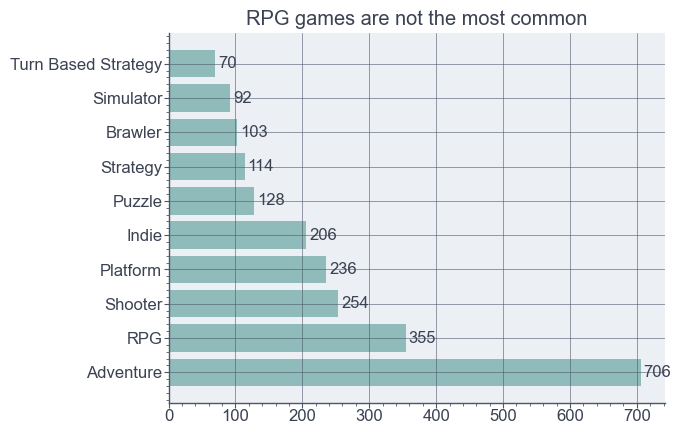

In [17]:
most_common_genres = genres_df["Genres"].value_counts().nlargest(10)

bar_chart = plt.barh(most_common_genres.index, most_common_genres.values)
plt.bar_label(bar_chart, padding=2)
plt.title("RPG games are not the most common")
plt.show()

## Rating Distribution

Are most games rated highly? How is the dataset skewed?

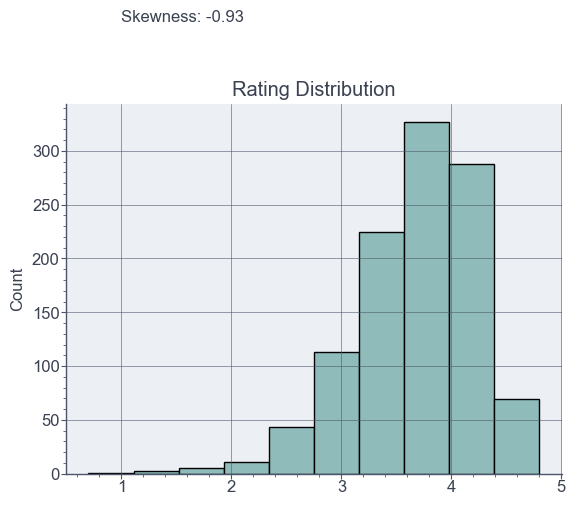

In [18]:
ratings_skewness = sp.stats.skew(df.Rating) # -1 means distribution is left-skewed (negative skewness)

plt.hist(df.Rating, edgecolor="black", histtype="bar")
plt.title("Rating Distribution")
plt.text(1, 420, f"Skewness: {round(ratings_skewness, 2)}")
plt.ylabel("Count")
plt.show()

## Game Releases Over Time

Which years had the most game releases?

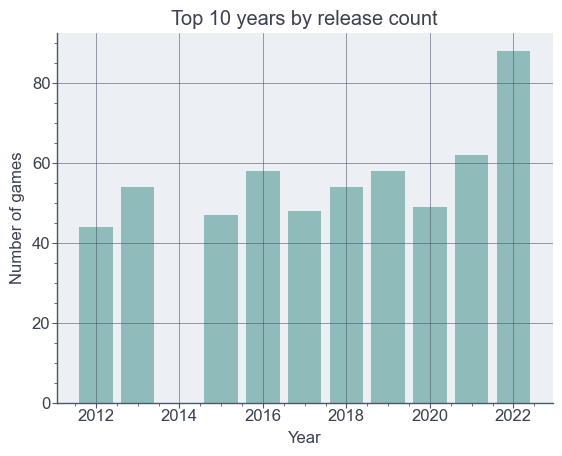

In [19]:
most_releases_per_year = df["Release Year"].value_counts().sort_values(ascending=False).head(10)

plt.bar(most_releases_per_year.index, most_releases_per_year.values)
plt.title("Top 10 years by release count")
plt.xlabel("Year")
plt.ylabel("Number of games")
plt.show()


Did releases increase after 2010?

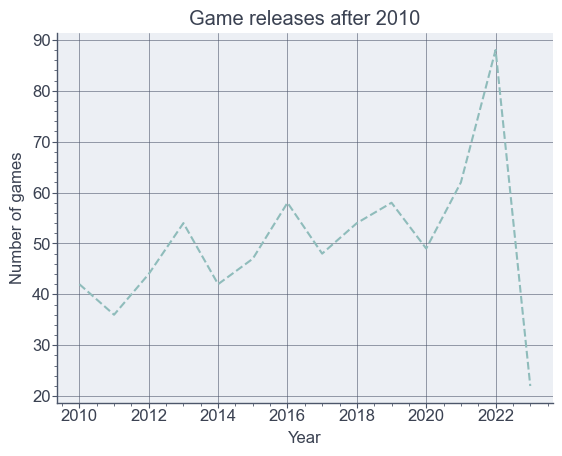

In [20]:
games_after_2010 = df[df["Release Year"] >= 2010]
games_after_2010_releases = games_after_2010.groupby("Release Year").size()

plt.plot(games_after_2010_releases.index, games_after_2010_releases.values, linestyle="dashed", linewidth=1.5)
plt.xlabel("Year")
plt.ylabel("Number of games")
plt.title("Game releases after 2010")
plt.show()

## Correlation Analysis

Do highly rated games get more plays?

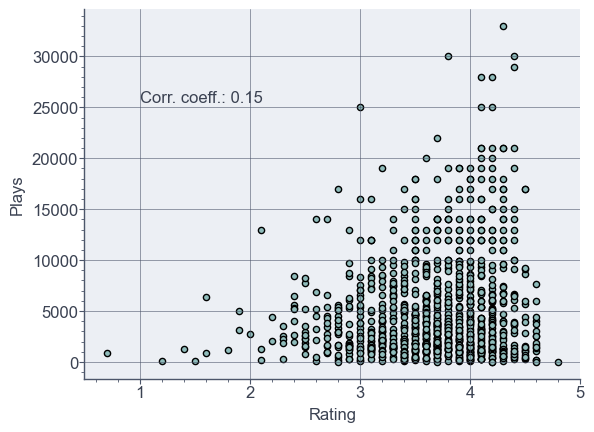

In [21]:
rating_plays_corr = df.Rating.corr(df.Plays, method="pearson")

plt.scatter(df.Rating, df.Plays, edgecolor="black", s=20)
plt.text(1, 25500, s=f"Corr. coeff.: {round(rating_plays_corr, 2)}")
plt.xlabel("Rating")
plt.ylabel("Plays")
plt.show()

Are wishlist counts related to ratings?

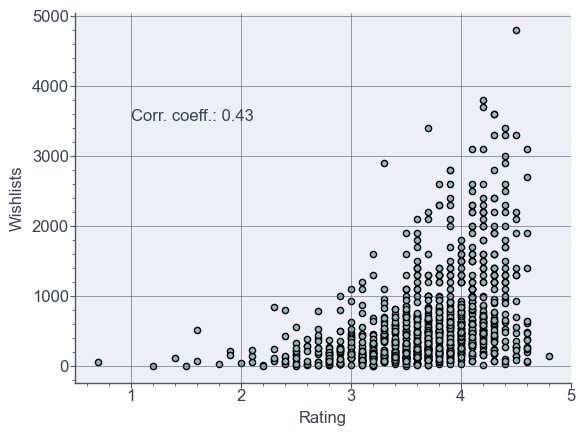

In [22]:
ratings_wishlists_corr = df.Rating.corr(df.Wishlist, method="pearson")

plt.scatter(df.Rating, df.Wishlist, edgecolor="black", s=20)
plt.text(1, 3500, s=f"Corr. coeff.: {round(ratings_wishlists_corr, 2)}")
plt.xlabel("Rating")
plt.ylabel("Wishlists")
plt.show()

## Most Played Games

Which games dominate plays? Do they also dominate ratings?

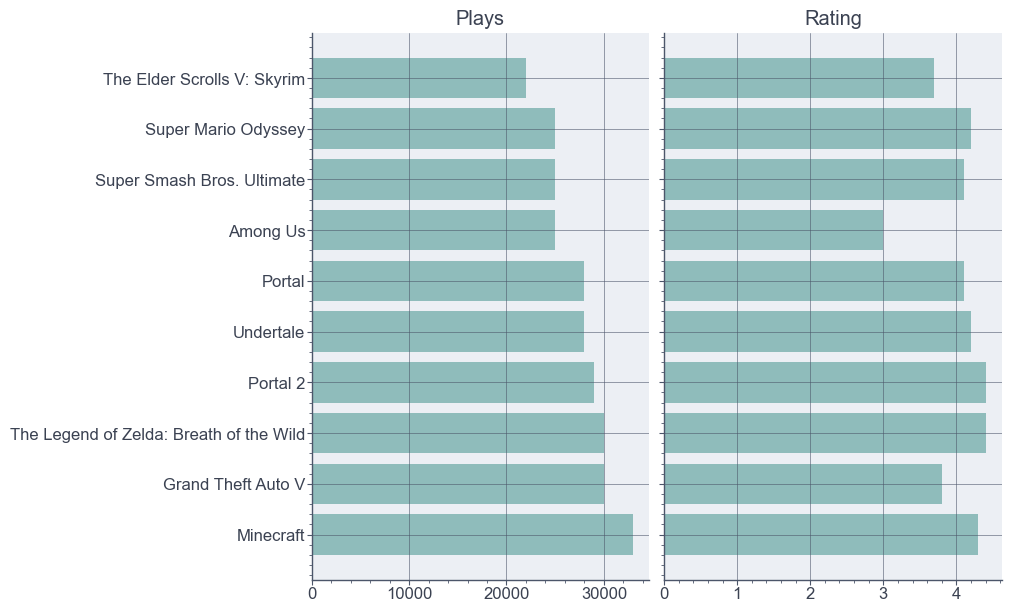

In [23]:
most_played_games_df = df.sort_values(by="Plays", ascending=False).iloc[0:10, :]

fig, axes = plt.subplots(nrows=1, ncols=2, constrained_layout=True, figsize=(10, 6), sharey=True)
axes[0].barh(most_played_games_df["Title"], most_played_games_df["Plays"])
axes[0].set_title("Plays")
axes[1].barh(most_played_games_df["Title"], most_played_games_df["Rating"])
axes[1].set_title("Rating")
plt.show()

## Backlog Analysis

Which games have the biggest backlogs?

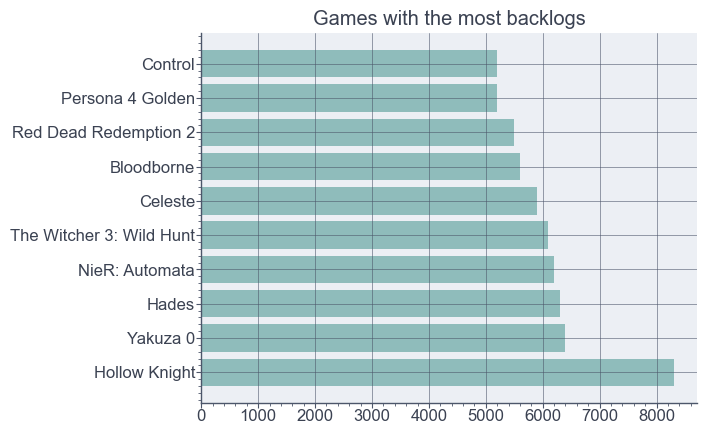

In [24]:
biggest_backlogs = df.sort_values(by="Backlogs", ascending=False).head(10)

plt.barh(biggest_backlogs["Title"], biggest_backlogs["Backlogs"])
plt.title("Games with the most backlogs")
plt.show()

Do players backlog longer RPGs more?

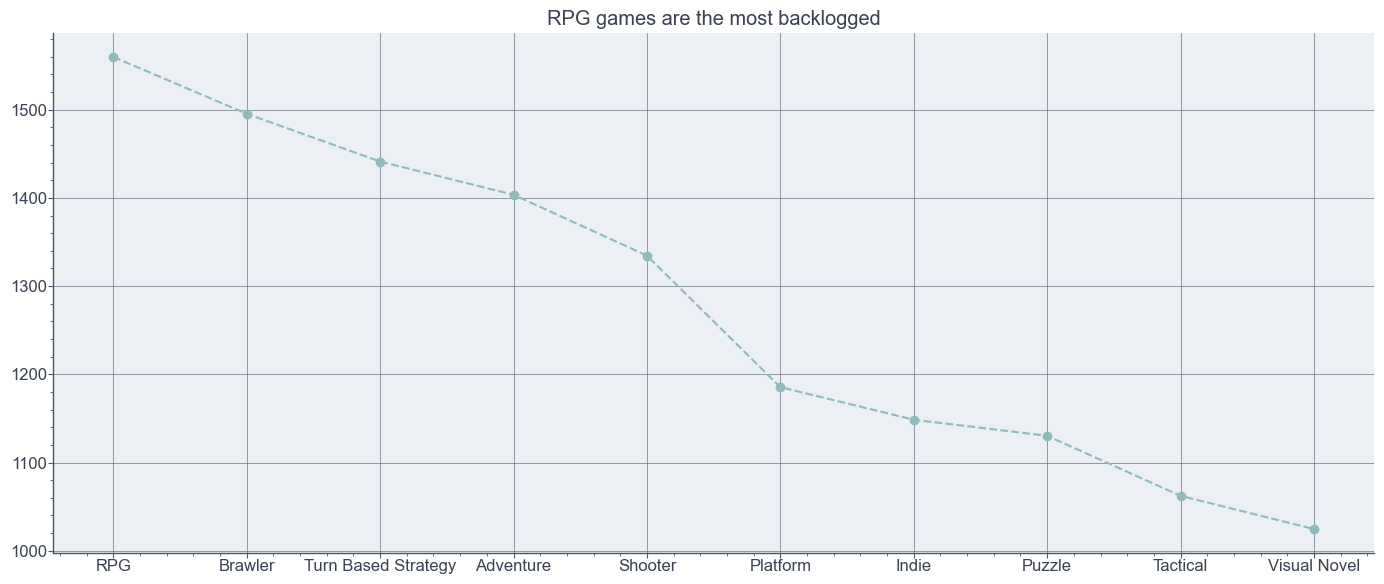

In [25]:
longer_rpgs_df = genres_df.groupby("Genres")["Backlogs"].mean().sort_values(ascending=False).reset_index().iloc[0:10, :]

plt.figure(figsize=(14, 6))
plt.plot(longer_rpgs_df["Genres"], longer_rpgs_df["Backlogs"], linewidth=1.5, linestyle="dashed", marker="o")
plt.title("RPG games are the most backlogged")
plt.tight_layout()
plt.show()

## Genre vs Rating Analysis

Which genres have the lowest average ratings? Are indie games rated better?

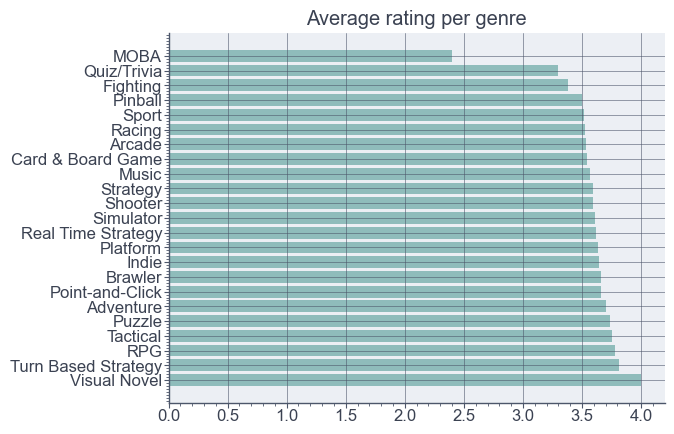

In [26]:
avg_ratings_per_genre = genres_df.groupby("Genres")["Rating"].agg("mean").sort_values(ascending=False).reset_index()

plt.barh(avg_ratings_per_genre.Genres, avg_ratings_per_genre.Rating)
plt.title("Average rating per genre")
plt.show()

## Linear Regression

In [27]:
X = df[["Plays", "Wishlist", "Backlogs", "Number of Reviews", "Times Listed"]]
y = df["Rating"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
predictions = model.predict(X_test)

In [31]:
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, predictions)
r2_scor = r2_score(y_test, predictions)

print(f"MAE: {mae}")
print(f"R² score: {r2_scor}")

MAE: 0.3156686587137862
R² score: 0.3198649464562999


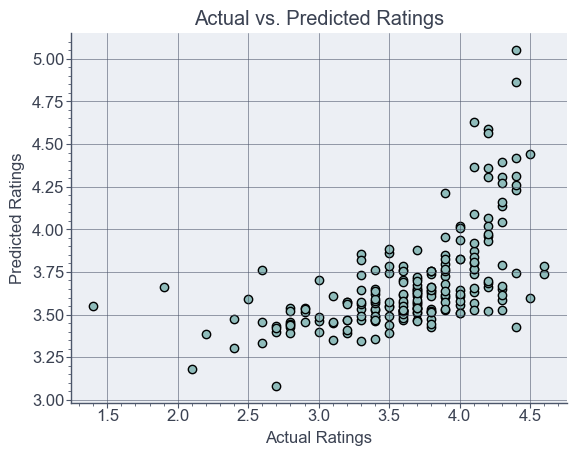

In [32]:
plt.scatter(y_test, predictions, edgecolor="black")
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs. Predicted Ratings")
plt.show()

## Conclusions

### Data Analysis

1. The most rated games are Elden Ring, Tokyo Necro, Disco Elysium, Bloodborne and Outer Wilds.
2. Adventure games are the most popular game genre, with RPGs coming second.
3. The ratings distribution is left-skewed, indicating that most games received relatively high ratings.
4. 2022 saw the most game releases and the trend has been up for over 10 years.
5. Highly rated games don’t necessarily get more plays, as confirmed by the 0.15 correlation coefficient. Wishlist counts showed a stronger relationship with ratings (correlation of 0.43) than plays did.
6. The most played games don’t have the highest ratings. Two examples are the GTA V, which has a rating just below 4, and Among Us, having a 3.
7. The most backlogged game is Hollow Knight, with over 8000 backlogs. Something to note is that RPG titles have, on average, the most backlog since, presumably, people know that they require a huge time investment.
8. Among genres with sufficient entries, MOBA games have the lowest average rating: just below 2.5, while Visual Novel holds the first position, with a 4.


### Machine Learning

9. The linear regression model used to predict ratings had a mean absolute error of 0.32, meaning that the predictions were off by 0.32 rating points on average. The r2 score of 0.32 means that the features explain about 32% of rating differences between games.